# <img src="https://github.com/JuliaLang/julia-logo-graphics/raw/master/images/julia-logo-color.png" height="100" /> _Colab Notebook Template_

## Instructions
1. Work on a copy of this notebook: _File_ > _Save a copy in Drive_ (you will need a Google account). Alternatively, you can download the notebook using _File_ > _Download .ipynb_, then upload it to [Colab](https://colab.research.google.com/).
2. If you need a GPU: _Runtime_ > _Change runtime type_ > _Harware accelerator_ = _GPU_.
3. Execute the following cell (click on it and press Ctrl+Enter) to install Julia, IJulia and other packages (if needed, update `JULIA_VERSION` and the other parameters). This takes a couple of minutes.
4. Reload this page (press Ctrl+R, or ⌘+R, or the F5 key) and continue to the next section.

_Notes_:
* If your Colab Runtime gets reset (e.g., due to inactivity), repeat steps 2, 3 and 4.
* After installation, if you want to change the Julia version or activate/deactivate the GPU, you will need to reset the Runtime: _Runtime_ > _Factory reset runtime_ and repeat steps 3 and 4.

In [ ]:
%%shell
set -e

#---------------------------------------------------#
JULIA_VERSION="1.8.2" # any version ≥ 0.7.0
JULIA_PACKAGES="IJulia BenchmarkTools"
JULIA_PACKAGES_IF_GPU="CUDA" # or CuArrays for older Julia versions
JULIA_NUM_THREADS=2
#---------------------------------------------------#

if [ -z `which julia` ]; then
  # Install Julia
  JULIA_VER=`cut -d '.' -f -2 <<< "$JULIA_VERSION"`
  echo "Installing Julia $JULIA_VERSION on the current Colab Runtime..."
  BASE_URL="https://julialang-s3.julialang.org/bin/linux/x64"
  URL="$BASE_URL/$JULIA_VER/julia-$JULIA_VERSION-linux-x86_64.tar.gz"
  wget -nv $URL -O /tmp/julia.tar.gz # -nv means "not verbose"
  tar -x -f /tmp/julia.tar.gz -C /usr/local --strip-components 1
  rm /tmp/julia.tar.gz

  # Install Packages
  nvidia-smi -L &> /dev/null && export GPU=1 || export GPU=0
  if [ $GPU -eq 1 ]; then
    JULIA_PACKAGES="$JULIA_PACKAGES $JULIA_PACKAGES_IF_GPU"
  fi
  for PKG in `echo $JULIA_PACKAGES`; do
    echo "Installing Julia package $PKG..."
    julia -e 'using Pkg; pkg"add '$PKG'; precompile;"' &> /dev/null
  done

  # Install kernel and rename it to "julia"
  echo "Installing IJulia kernel..."
  julia -e 'using IJulia; IJulia.installkernel("julia", env=Dict(
      "JULIA_NUM_THREADS"=>"'"$JULIA_NUM_THREADS"'"))'
  KERNEL_DIR=`julia -e "using IJulia; print(IJulia.kerneldir())"`
  KERNEL_NAME=`ls -d "$KERNEL_DIR"/julia*`
  mv -f $KERNEL_NAME "$KERNEL_DIR"/julia

  echo ''
  echo "Successfully installed `julia -v`!"
  echo "Please reload this page (press Ctrl+R, ⌘+R, or the F5 key) then"
  echo "jump to the 'Checking the Installation' section."
fi

Installing Julia 1.8.2 on the current Colab Runtime...
2024-01-25 03:49:46 URL:https://storage.googleapis.com/julialang2/bin/linux/x64/1.8/julia-1.8.2-linux-x86_64.tar.gz [135859273/135859273] -> "/tmp/julia.tar.gz" [1]
Installing Julia package IJulia...
Installing Julia package BenchmarkTools...
Installing IJulia kernel...


# Checking the Installation
The `versioninfo()` function should print your Julia version and some other info about the system:

In [1]:
versioninfo()

Julia Version 1.8.2
Commit 36034abf260 (2022-09-29 15:21 UTC)
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 2 × Intel(R) Xeon(R) CPU @ 2.20GHz
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-13.0.1 (ORCJIT, broadwell)
  Threads: 2 on 2 virtual cores
Environment:
  LD_LIBRARY_PATH = /usr/local/nvidia/lib:/usr/local/nvidia/lib64
  JULIA_NUM_THREADS = 2


In [2]:
using Pkg
Pkg.add("CSV")
Pkg.add("DataFrames")
Pkg.add("Git")
Pkg.add("Lathe")
Pkg.add("Plots")
Pkg.add("Images")
Pkg.add("Colors")
Pkg.add("Flux")
Pkg.add("MLDataUtils")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed TableTraits ───────────────── v1.0.1
   Installed DataAPI ───────────────────── v1.16.0
   Installed InlineStrings ─────────────── v1.4.0
   Installed SentinelArrays ────────────── v1.4.1
   Installed PooledArrays ──────────────── v1.4.3
   Installed IteratorInterfaceExtensions ─ v1.0.0
   Installed DataValueInterfaces ───────── v1.0.0
   Installed WorkerUtilities ───────────── v1.6.1
   Installed OrderedCollections ────────── v1.6.3
   Installed WeakRefStrings ────────────── v1.4.2
   Installed FilePathsBase ─────────────── v0.9.21
   Installed TranscodingStreams ────────── v0.10.2
   Installed Compat ────────────────────── v4.12.0
   Installed CodecZlib ─────────────────── v0.7.3
   Installed CSV ───────────────────────── v0.10.12
   Installed Tables ────────────────────── v1.11.1
    Updating `~/.julia/environments/v1.8/Project.toml`
  [336ed68f] + CSV v0.10.12
    Updating `~/.

In [3]:
using Git

# Replace "repository_url" with the actual URL of your Git repository
repository_url = ""
clone_dir = "/content/"  # Change this to the desired local directory name

run(`git clone https://github.com/Parthiee/Gesture-Recognition-for-Sign-Language`)

Cloning into 'Gesture-Recognition-for-Sign-Language'...


Process(`git clone https://github.com/Parthiee/Gesture-Recognition-for-Sign-Language`, ProcessExited(0))

In [4]:
using CSV
using DataFrames

df = CSV.read("/content/Gesture-Recognition-for-Sign-Language/data/sign_mnist_train.csv", DataFrame)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12
,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64
1,3,107,118,127,134,139,143,146,150,153,156,158,160
2,6,155,157,156,156,156,157,156,158,158,157,158,156
3,2,187,188,188,187,187,186,187,188,187,186,185,185
4,2,211,211,212,212,211,210,211,210,210,211,209,207
5,13,164,167,170,172,176,179,180,184,185,186,188,189
6,16,161,168,172,173,178,184,189,193,196,202,206,208
7,8,134,134,135,135,136,137,137,138,138,138,139,138
8,22,114,42,74,99,104,109,117,127,142,152,155,162
9,3,169,174,176,180,183,185,187,188,190,191,191,191


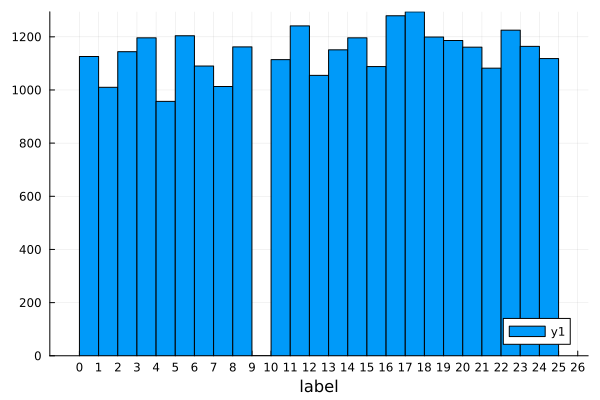

In [5]:
using Plots


histogram(df[!,"label"], xlabel="label", xticks = 0:1:26,)

In [6]:
uniqueEntries = sort(unique(df[:,"label"]))
println(uniqueEntries)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


In [7]:
using Lathe.preprocess: TrainTestSplit
train, test = TrainTestSplit(df,0.8)

trainY = train[!,"label"]
trainX = select!(train, Not([:label]))

testY = test[!,"label"]
testX = select!(test, Not([:label]))

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13
,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64
1,107,118,127,134,139,143,146,150,153,156,158,160,163
2,164,167,170,172,176,179,180,184,185,186,188,189,189
3,161,168,172,173,178,184,189,193,196,202,206,208,212
4,134,134,135,135,136,137,137,138,138,138,139,138,138
5,169,174,176,180,183,185,187,188,190,191,191,191,191
6,133,135,141,146,150,155,158,159,163,165,166,167,169
7,86,87,89,93,104,114,122,131,137,140,142,146,151
8,90,98,105,110,118,124,126,127,131,136,139,142,145
9,148,153,156,157,158,158,158,158,160,160,160,159,158


In [8]:
trainX = trainX./256
testX = testX./256

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.417969,0.460938,0.496094,0.523438,0.542969,0.558594,0.570312,0.585938,0.597656,0.609375
2,0.640625,0.652344,0.664062,0.671875,0.6875,0.699219,0.703125,0.71875,0.722656,0.726562
3,0.628906,0.65625,0.671875,0.675781,0.695312,0.71875,0.738281,0.753906,0.765625,0.789062
4,0.523438,0.523438,0.527344,0.527344,0.53125,0.535156,0.535156,0.539062,0.539062,0.539062
5,0.660156,0.679688,0.6875,0.703125,0.714844,0.722656,0.730469,0.734375,0.742188,0.746094
6,0.519531,0.527344,0.550781,0.570312,0.585938,0.605469,0.617188,0.621094,0.636719,0.644531
7,0.335938,0.339844,0.347656,0.363281,0.40625,0.445312,0.476562,0.511719,0.535156,0.546875
8,0.351562,0.382812,0.410156,0.429688,0.460938,0.484375,0.492188,0.496094,0.511719,0.53125
9,0.578125,0.597656,0.609375,0.613281,0.617188,0.617188,0.617188,0.617188,0.625,0.625


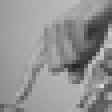

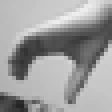

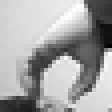

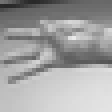

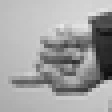

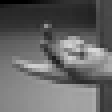

In [42]:
using Images
function plot_image(pixel_values)
    img_matrix = reshape(pixel_values, (28, 28))  # Reshape pixel values into a 3x3 matrix
    img = Gray.(img_matrix)  # Convert to Gray image type
    return img # Display the image using heatmap
end
for i in 1:6
  arr = Array(trainX[i,:])
  display(plot_image(arr))
end

#println(arr)


In [10]:
#Convert dataframes to Array

trainY = Float32.(Array(trainY))
trainX = Float32.(Array(trainX))

testY = Float32.(Array(testY))
testX = Float32.(Array(testX))


5529×784 Matrix{Float32}:
 0.417969  0.460938  0.496094   0.523438  0.542969  …  0.804688  0.796875   0.792969  0.789062
 0.640625  0.652344  0.664062   0.671875  0.6875       0.613281  0.636719   0.640625  0.699219
 0.628906  0.65625   0.671875   0.675781  0.695312     0.1875    0.929688   0.996094  0.996094
 0.523438  0.523438  0.527344   0.527344  0.53125      0.699219  0.707031   0.707031  0.699219
 0.660156  0.679688  0.6875     0.703125  0.714844     0.367188  0.289062   0.238281  0.222656
 0.519531  0.527344  0.550781   0.570312  0.585938  …  0.367188  0.367188   0.363281  0.359375
 0.335938  0.339844  0.347656   0.363281  0.40625      0.332031  0.476562   0.550781  0.5
 0.351562  0.382812  0.410156   0.429688  0.460938     0.839844  0.835938   0.835938  0.839844
 0.578125  0.597656  0.609375   0.613281  0.617188     0.683594  0.675781   0.667969  0.652344
 0.691406  0.691406  0.699219   0.703125  0.703125     0.851562  0.859375   0.847656  0.832031
 0.414062  0.417969  0.429688

In [83]:
using Flux

model = Chain(
    Dense(784 => 100, sigmoid),
    Dense(100 => 25, sigmoid),
    softmax
)


Chain(
  Dense(784 => 100, σ),                 # 78_500 parameters
  Dense(100 => 25, σ),                  # 2_525 parameters
  NNlib.softmax,
)                   # Total: 4 arrays, 81_025 parameters, 316.754 KiB.

In [45]:
function toDataLoader(X,Y)
  data = []
    for i in 1:size(trainX, 1)
      push!(data, (trainX[i, :], trainY[i]))
    end
    data = Flux.DataLoader(data, shuffle=true)

    return data
end

dataTrain = toDataLoader(trainX, trainY)


21926-element DataLoader(::Vector{Any}, shuffle=true)
  with first element:
  1-element Vector{Any}

In [46]:
function loss(model, x, y)
    loss_ = Flux.crossentropy(model(x), Flux.onehotbatch(y, 0:24))
    return loss_
end


function accuracy()
    correct = 0
    for index in 1:length(y_test)
        probs = model(testX[index,:])
        predicted_digit = argmax(probs)[1]-1
        if predicted_digit == y_test[index]
            correct +=1
        end
    end
    return correct/length(y_test)
end

accuracy (generic function with 1 method)

# Gradient Descent Optimization

In [47]:

optimizer = opt = Flux.setup(Descent(), model)

y_test = testY
x_test = testX

epochs = Int64[]
loss_on_train_gd = Float32[]
loss_on_test_gd = Float32[]
accuracy_train_gd = Float32[]

for epoch in 1:50
    loss_ = []
    Flux.train!(loss, model, dataTrain.data, optimizer)
    acc = accuracy()
    push!(accuracy_train_gd,acc)
    push!(epochs, epoch)
    for index in 1 : length(trainX[1,:])
          push!(loss_, loss(model, trainX[index,:], trainY[index]))
    end

    loss_avg_train = sum(loss_.^2)/length(loss_)
    push!(loss_on_train_gd, loss_avg_train)

    empty!(loss_)

    for index in 1 : length(testX[1,:])
          push!(loss_, loss(model, testX[index,:], testY[index]))
    end

    loss_avg_test = sum(loss_.^2)/length(loss_)
    push!(loss_on_test_gd, loss_avg_test)

    println("train loss :  $loss_avg_train   test loss:  $loss_avg_test   accuracy : $acc   ")




end


train loss :  6.734465   test loss:  6.814846   accuracy : 0.4405860010851872   
train loss :  6.2821236   test loss:  6.354437   accuracy : 0.5143787303309821   
train loss :  6.0828495   test loss:  6.165133   accuracy : 0.584192439862543   
train loss :  5.959875   test loss:  6.0397663   accuracy : 0.6361005606800506   
train loss :  5.83959   test loss:  5.894775   accuracy : 0.6910833785494664   
train loss :  5.742552   test loss:  5.771351   accuracy : 0.7326822210164586   
train loss :  5.670681   test loss:  5.6839294   accuracy : 0.7610779526134925   
train loss :  5.5853353   test loss:  5.5945024   accuracy : 0.8012298788207632   
train loss :  5.538979   test loss:  5.5402184   accuracy : 0.8173268222101646   
train loss :  5.5073614   test loss:  5.498966   accuracy : 0.8558509676252487   
train loss :  5.483816   test loss:  5.465336   accuracy : 0.8806294085729789   
train loss :  5.4678817   test loss:  5.449807   accuracy : 0.8967263519623802   
train loss :  5.43706

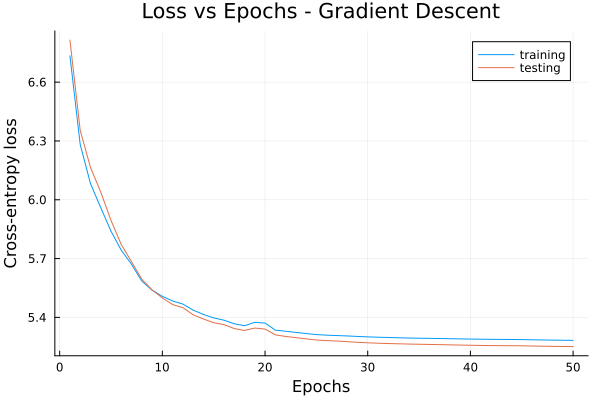

"/content/Loss-Epochs-GD.png"

In [51]:
plot(loss_on_train_gd, ylabel="Cross-entropy loss", xlabel="Epochs", labels="training", title="Loss vs Epochs - Gradient Descent")
display(plot!(loss_on_test_gd, labels="testing"))
savefig("/content/Loss-Epochs-GD.png")


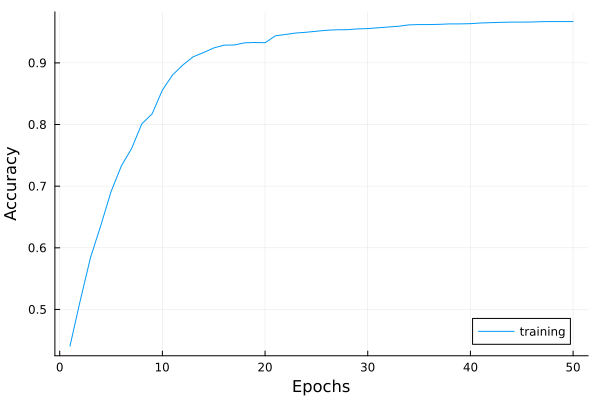

"/content/Accuracy-Epochs-GD.png"

In [65]:
display(plot(accuracy_train_gd, ylabel="Accuracy", xlabel="Epochs", labels="training"))
savefig("/content/Accuracy-Epochs-GD.png")


# AdamW Optimization

In [74]:
optimizer = opt = Flux.setup(AdamW(), model)

y_test = testY
x_test = testX

epochs = Int64[]
loss_on_train_aw = Float32[]
loss_on_test_aw = Float32[]
accuracy_train_aw = Float32[]

for epoch in 1:50
    loss_ = []
    Flux.train!(loss, model, dataTrain.data, optimizer)
    acc = accuracy()
    push!(accuracy_train_aw,acc)
    push!(epochs, epoch)
    for index in 1 : length(trainX[1,:])
          push!(loss_, loss(model, trainX[index,:], trainY[index]))
    end

    loss_avg_train = sum(loss_.^2)/length(loss_)
    push!(loss_on_train_aw, loss_avg_train)

    empty!(loss_)

    for index in 1 : length(testX[1,:])
          push!(loss_, loss(model, testX[index,:], testY[index]))
    end

    loss_avg_test = sum(loss_.^2)/length(loss_)
    push!(loss_on_test_aw, loss_avg_test)

    println("train loss :  $loss_avg_train   test loss:  $loss_avg_test   accuracy : $acc   ")




end


train loss :  6.8887143   test loss:  7.013981   accuracy : 0.44311810453969974   
train loss :  6.5006127   test loss:  6.6696835   accuracy : 0.5179960209802857   
train loss :  6.388771   test loss:  6.50932   accuracy : 0.5141978657985169   
train loss :  6.085096   test loss:  6.179389   accuracy : 0.6073431000180864   
train loss :  6.0544734   test loss:  6.2022443   accuracy : 0.599023331524688   
train loss :  5.882045   test loss:  5.9323587   accuracy : 0.6568999819135467   
train loss :  5.8064795   test loss:  5.858303   accuracy : 0.7100741544583107   
train loss :  5.860567   test loss:  5.9586406   accuracy : 0.6784228612769035   
train loss :  5.8648047   test loss:  5.910924   accuracy : 0.6784228612769035   
train loss :  5.6959   test loss:  5.7149744   accuracy : 0.7287032013022247   
train loss :  5.7073483   test loss:  5.761747   accuracy : 0.7438958220293   
train loss :  5.8571754   test loss:  5.9562707   accuracy : 0.6605172725628504   
train loss :  5.93399

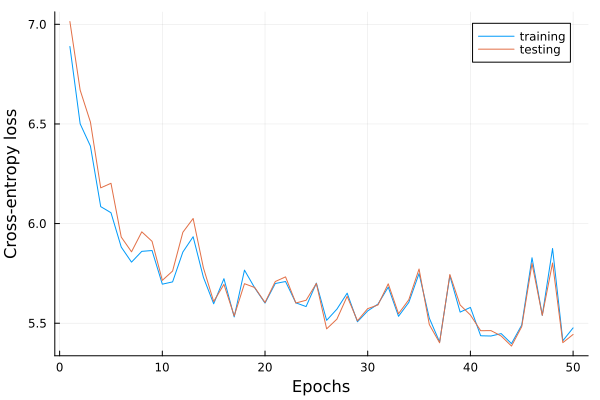

"/content/Loss-Epochs-AdamW.png"

In [75]:
plot(loss_on_train_aw, ylabel="Cross-entropy loss", xlabel="Epochs", labels="training")
display(plot!(loss_on_test_aw, labels="testing"))
savefig("/content/Loss-Epochs-AdamW.png")

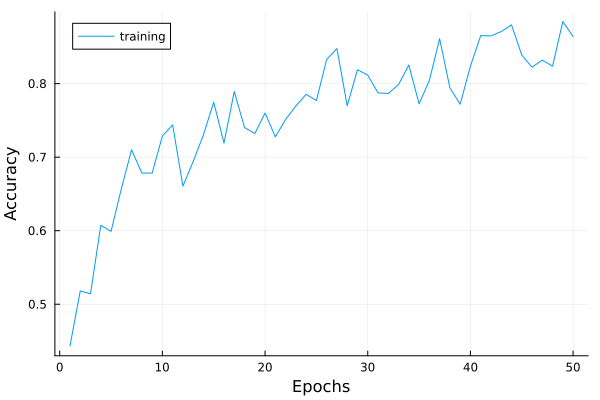

"/content/Accuracy-Epochs-AdamW.png"

In [76]:
display(plot(accuracy_train_aw, ylabel="Accuracy", xlabel="Epochs", labels="training"))
savefig("/content/Accuracy-Epochs-AdamW.png")

In [62]:
optimizer = opt = Flux.setup(Momentum(0.01, 0.99), model)

y_test = testY
x_test = testX

epochs = Int64[]
loss_on_train_momentum = Float32[]
loss_on_test_momentum = Float32[]
accuracy_train_momentum = Float32[]

for epoch in 1:50
    loss_ = []
    Flux.train!(loss, model, dataTrain.data, optimizer)
    acc = accuracy()
    push!(accuracy_train_momentum,acc)
    push!(epochs, epoch)
    for index in 1 : length(trainX[1,:])
          push!(loss_, loss(model, trainX[index,:], trainY[index]))
    end

    loss_avg_train = sum(loss_.^2)/length(loss_)
    push!(loss_on_train_momentum, loss_avg_train)

    empty!(loss_)

    for index in 1 : length(testX[1,:])
          push!(loss_, loss(model, testX[index,:], testY[index]))
    end

    loss_avg_test = sum(loss_.^2)/length(loss_)
    push!(loss_on_test_momentum, loss_avg_test)

    println("train loss :  $loss_avg_train   test loss:  $loss_avg_test   accuracy : $acc   ")




end


train loss :  10.254202   test loss:  10.301037   accuracy : 0.045758726713691446   
train loss :  10.332285   test loss:  10.434364   accuracy : 0.045758726713691446   
train loss :  10.253821   test loss:  10.300612   accuracy : 0.045758726713691446   
train loss :  10.196951   test loss:  10.196938   accuracy : 0.045758726713691446   
train loss :  10.196947   test loss:  10.19696   accuracy : 0.045758726713691446   
train loss :  10.196922   test loss:  10.196967   accuracy : 0.045758726713691446   
train loss :  10.196911   test loss:  10.196929   accuracy : 0.045758726713691446   
train loss :  10.338412   test loss:  10.375841   accuracy : 0.045758726713691446   
train loss :  10.338268   test loss:  10.375694   accuracy : 0.045758726713691446   
train loss :  10.196845   test loss:  10.196848   accuracy : 0.045758726713691446   
train loss :  10.385109   test loss:  10.329013   accuracy : 0.045758726713691446   
train loss :  10.196898   test loss:  10.196941   accuracy : 0.045

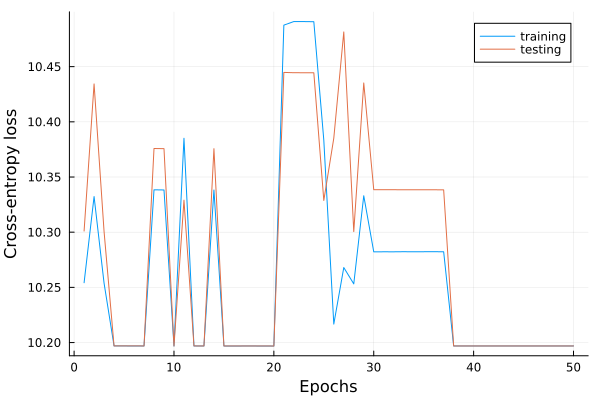

"/content/Loss-Epochs-Momentum.png"

In [63]:
plot(loss_on_train_momentum, ylabel="Cross-entropy loss", xlabel="Epochs", labels="training")
display(plot!(loss_on_test_momentum, labels="testing"))
savefig("/content/Loss-Epochs-Momentum.png")

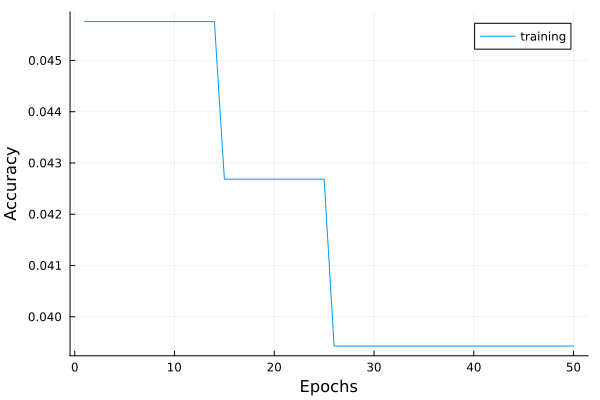

"/content/Accuracy-Epochs-Momentum.png"

In [67]:
display(plot(accuracy_train_momentum, ylabel="Accuracy", xlabel="Epochs", labels="training"))
savefig("/content/Accuracy-Epochs-Momentum.png")

In [80]:
optimizer = opt = Flux.setup(AdaGrad(0.001), model)

y_test = testY
x_test = testX

epochs = Int64[]
loss_on_train_adagrad = Float32[]
loss_on_test_adagrad = Float32[]
accuracy_train_adagrad = Float32[]

for epoch in 1:100
    loss_ = []
    Flux.train!(loss, model, dataTrain.data, optimizer)
    acc = accuracy()
    push!(accuracy_train_adagrad,acc)
    push!(epochs, epoch)
    for index in 1 : length(trainX[1,:])
          push!(loss_, loss(model, trainX[index,:], trainY[index]))
    end

    loss_avg_train = sum(loss_.^2)/length(loss_)
    push!(loss_on_train_adagrad, loss_avg_train)

    empty!(loss_)

    for index in 1 : length(testX[1,:])
          push!(loss_, loss(model, testX[index,:], testY[index]))
    end

    loss_avg_test = sum(loss_.^2)/length(loss_)
    push!(loss_on_test_adagrad, loss_avg_test)

    println("train loss :  $loss_avg_train   test loss:  $loss_avg_test   accuracy : $acc   ")




end


train loss :  9.8330145   test loss:  9.884978   accuracy : 0.19768493398444564   
train loss :  9.680028   test loss:  9.732079   accuracy : 0.24272020256827637   
train loss :  9.569618   test loss:  9.619672   accuracy : 0.26478567552902876   
train loss :  9.477958   test loss:  9.528451   accuracy : 0.28359558690540787   
train loss :  9.399016   test loss:  9.450394   accuracy : 0.3051184662687647   
train loss :  9.32918   test loss:  9.3813   accuracy : 0.31886417073611867   
train loss :  9.266121   test loss:  9.318912   accuracy : 0.3306203653463556   
train loss :  9.20838   test loss:  9.261807   accuracy : 0.3407487791644059   
train loss :  9.154965   test loss:  9.209014   accuracy : 0.35051546391752575   
train loss :  9.105177   test loss:  9.15983   accuracy : 0.35720745161873757   
train loss :  9.058478   test loss:  9.113729   accuracy : 0.36064387773557605   
train loss :  9.014471   test loss:  9.070303   accuracy : 0.3644420329173449   
train loss :  8.972826  

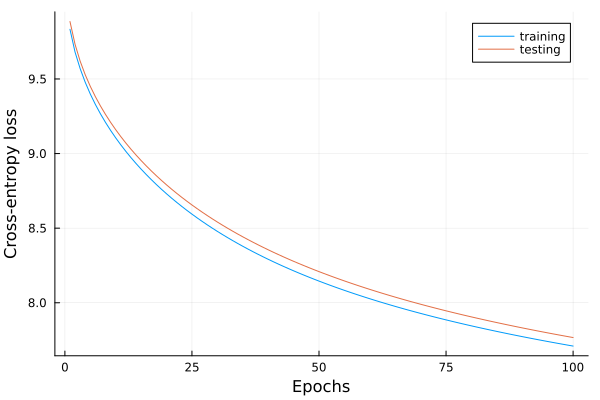

"/content/Loss-Epochs-AdaGrad.png"

In [81]:
plot(loss_on_train_adagrad, ylabel="Cross-entropy loss", xlabel="Epochs", labels="training")
display(plot!(loss_on_test_adagrad, labels="testing"))
savefig("/content/Loss-Epochs-AdaGrad.png")

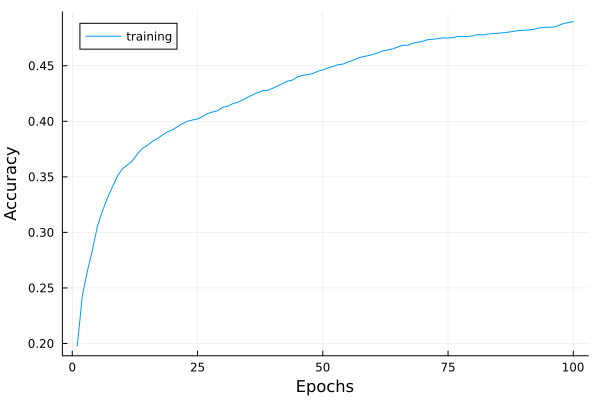

"/content/Accuracy-Epochs-AdaGrad.png"

In [82]:
display(plot(accuracy_train_adagrad, ylabel="Accuracy", xlabel="Epochs", labels="training"))
savefig("/content/Accuracy-Epochs-AdaGrad.png")

In [84]:
optimizer = opt = Flux.setup(AdaBelief(0.001, (0.9, 0.8)), model)

y_test = testY
x_test = testX

epochs = Int64[]
loss_on_train_adabelief = Float32[]
loss_on_test_adabelief = Float32[]
accuracy_train_adabelief = Float32[]

for epoch in 1:50
    loss_ = []
    Flux.train!(loss, model, dataTrain.data, optimizer)
    acc = accuracy()
    push!(accuracy_train_adabelief,acc)
    push!(epochs, epoch)
    for index in 1 : length(trainX[1,:])
          push!(loss_, loss(model, trainX[index,:], trainY[index]))
    end

    loss_avg_train = sum(loss_.^2)/length(loss_)
    push!(loss_on_train_adabelief, loss_avg_train)

    empty!(loss_)

    for index in 1 : length(testX[1,:])
          push!(loss_, loss(model, testX[index,:], testY[index]))
    end

    loss_avg_test = sum(loss_.^2)/length(loss_)
    push!(loss_on_test_adabelief, loss_avg_test)

    println("train loss :  $loss_avg_train   test loss:  $loss_avg_test   accuracy : $acc   ")




end


train loss :  10.179542   test loss:  10.180112   accuracy : 0.03979019714234039   
train loss :  9.791745   test loss:  9.878655   accuracy : 0.13402061855670103   
train loss :  8.733411   test loss:  8.921164   accuracy : 0.33260987520347257   
train loss :  7.77248   test loss:  8.054963   accuracy : 0.5268583830710798   
train loss :  7.0794907   test loss:  7.3208156   accuracy : 0.6013745704467354   
train loss :  6.7567163   test loss:  6.858685   accuracy : 0.6776994031470429   
train loss :  6.510319   test loss:  6.5424113   accuracy : 0.7335865436787846   
train loss :  6.5455914   test loss:  6.589277   accuracy : 0.7189365165491047   
train loss :  6.3946376   test loss:  6.4643307   accuracy : 0.7417254476397178   
train loss :  6.1869164   test loss:  6.3009806   accuracy : 0.7742810634834509   
train loss :  6.1192307   test loss:  6.201447   accuracy : 0.7905588714053174   
train loss :  6.1862135   test loss:  6.26626   accuracy : 0.7920057876650389   
train loss :  

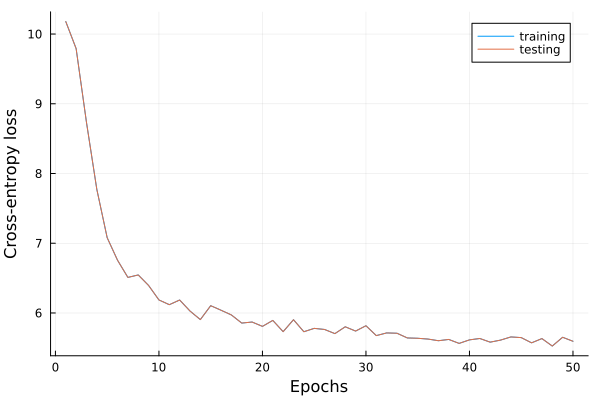

"/content/Loss-Epochs-AdaBelief.png"

In [85]:
plot(loss_on_train_adabelief, ylabel="Cross-entropy loss", xlabel="Epochs", labels="training")
display(plot!(loss_on_train_adabelief, labels="testing"))
savefig("/content/Loss-Epochs-AdaBelief.png")

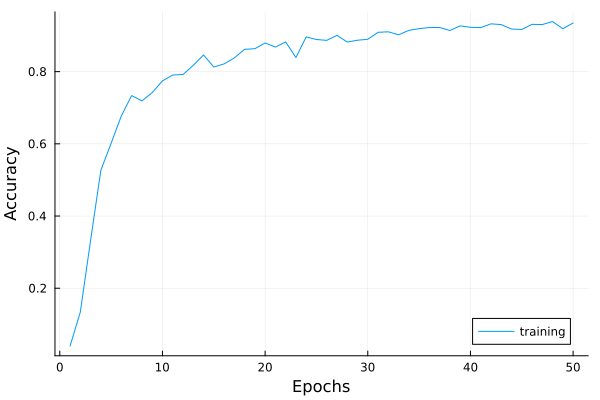

"/content/Accuracy-Epochs-AdaBelief.png"

In [87]:
display(plot(accuracy_train_adabelief, ylabel="Accuracy", xlabel="Epochs", labels="training"))
savefig("/content/Accuracy-Epochs-AdaBelief.png")